<a href="https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/copyMP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
clc; clear; close all;


%  KONSTANTA DAN PARAMETER

eta   = 1.85e-5;
g     = 9.81;
rho_o = 875;
rho_f = 1.29;
l     = 6.00e-3;
d     = 1.00e-3;
e_real = 1.602e-19;
drho  = rho_o - rho_f;


%  DATA PENGAMATAN

raw = [
   10.04,  584.00,   4.07,  403.00;
    5.01,  581.00,   5.82,  280.00;
   11.47,  580.00,  13.30,  266.00;
   11.80,  580.00,  14.41,  390.00;
    7.57,  579.00,   8.21,  275.00;
   16.98,  580.00,   3.63,  118.00;
   12.99,  579.00,  10.93,  291.00;
    8.38,  576.00,   9.16,  348.00;
   14.77,  578.00,   9.01,  257.00;
   12.92,  577.00,  11.70,  263.00;
    8.75,  437.30,  24.06,  317.40;
    8.00,  235.60,  24.92,  181.30;
   12.46,  235.10,  23.04,  153.10;
    6.82,  294.20,  24.79,  226.00;
   12.60,  357.90,  21.76,  226.00;
    9.31,  233.00,  31.94,  179.80;
    7.19,  264.20,  27.14,  208.60;
   11.17,  287.70,  19.71,  181.80;
   28.31,  113.30,  43.30,   67.30;
   15.61,  142.50,  28.82,   94.50;
];
N  = size(raw,1);
td = raw(:,1);  tu = raw(:,3);
Us = raw(:,4);  Ur = raw(:,2);


%  HITUNG Vd, Vu, r, qf, qr, qavg

Vd        = d ./ td;
Vu        = d ./ tu;
r         = sqrt( (9.*eta.*Vd) ./ (2.*g.*drho) );
sqrt_term = sqrt( (eta.*Vd)    ./ (2.*g.*drho) );
qf        = (18.*pi.*eta.*l.*Vd      ./Us) .* sqrt_term;
qr        = (18.*pi.*eta.*l.*(Vd+Vu) ./Ur) .* sqrt_term;
qavg      = (qf + qr) / 2;
fprintf('===================================================================================\n');
fprintf('  No |    Vd (m/s)  |    Vu (m/s)  |    r (m)     |    qf (C)    |    qr (C)    |   qavg (C)\n');
fprintf('===================================================================================\n');
for i = 1:N
   fprintf('  %2d | %10.4e | %10.4e | %10.4e | %10.4e | %10.4e | %10.4e\n', ...
       i, Vd(i), Vu(i), r(i), qf(i), qr(i), qavg(i));
end
fprintf('===================================================================================\n\n');

%  MATRIKS SELISIH BERPASANGAN (190 kombinasi)

diff_list = zeros(N*(N-1)/2, 1);
idx = 0;
fprintf('--- MATRIKS SELISIH |qi - qj| (x10^-19 C) - Segitiga Bawah ---\n');
fprintf('%5s', '');
for j = 1:N; fprintf('%8d', j); end
fprintf('\n%s\n', repmat('-', 1, 5+8*N));
for i = 1:N
   fprintf('%3d  ', i);
   for j = 1:N
       if j < i
           val      = abs(qavg(i) - qavg(j));
           idx      = idx + 1;
           diff_list(idx) = val;
           fprintf('%8.3f', val*1e19);
       elseif j == i
           fprintf('%8s', '--');
       else
           fprintf('%8s', '');
       end
   end
   fprintf('\n');
end
fprintf('\nTotal kombinasi: %d\n\n', length(diff_list));
dq = diff_list * 1e19;


%  HISTOGRAM + GAUSSIAN FIT

lb = 0.50;
ub = 2.50;
peak1 = dq(dq >= lb & dq <= ub);
n1    = length(peak1);
mu1   = mean(peak1);
s1    = std(peak1);
SE1   = s1 / sqrt(n1);
e_hist = mu1 * 1e-19;
fprintf('--- HASIL GAUSSIAN FIT (Puncak 1e) ---\n');
fprintf('  Filter  : [%.2f, %.2f] x10^-19 C\n', lb, ub);
fprintf('  n data  : %d\n', n1);
fprintf('  e_hist  = (%.4f +- %.4f) x10^-19 C\n', mu1, SE1*1e19);
fprintf('  Galat   : %.2f%%\n\n', abs(e_hist-e_real)/e_real*100);

% Plot Histogram
figure('Name','Histogram Selisih Muatan','NumberTitle','off',...
      'Position',[50 100 860 560]);
nbins = 35;
histogram(dq, nbins, 'FaceColor',[0.20 0.47 0.75], ...
   'EdgeColor','white','FaceAlpha',0.85, ...
   'DisplayName','Semua Data (N=190)');
hold on;
ylims = ylim; ymax = ylims(2)*1.15; ylim([0 ymax]);
patch([lb ub ub lb],[0 0 ymax ymax],[0.75 0.75 0.75], ...
   'FaceAlpha',0.30,'EdgeColor','none', ...
   'DisplayName',sprintf('Area 1e [%.1f-%.1f]',lb,ub));
bin_width = (max(dq(:)) - min(dq(:))) / nbins;
x_fit = linspace(lb,ub,400);
g_fit = (n1*bin_width).*(1/(s1*sqrt(2*pi))).*exp(-0.5*((x_fit-mu1)/s1).^2);
plot(x_fit,g_fit,'r-','LineWidth',2.5,...
   'DisplayName',sprintf('Gaussian Fit (\\mu=%.2f)',mu1));
xline(mu1,'k--','LineWidth',1.8,...
   'Label',sprintf('  e_{est}=%.2fx10^{-19}C',mu1),...
   'LabelVerticalAlignment','top','FontSize',10);
xlabel('\Deltaq  Selisih Muatan (10^{-19} C)','FontSize',13);
ylabel('Frekuensi','FontSize',13);
title('Histogram Distribusi Selisih Muatan |q_i - q_j|','FontSize',14);
legend('Location','northeast','FontSize',10);
grid on; box on; set(gca,'FontSize',11); hold off;


%  BILANGAN KUANTISASI

n_q   = round(qavg / e_hist);
e_est = qavg ./ n_q;
fprintf('--- BILANGAN KUANTISASI ---\n');
fprintf('%4s | %14s | %14s | %14s | %4s | %16s\n', ...
   'No','qr (x1e-19)','qf (x1e-19)','qavg (x1e-19)','n','e_est (x1e-19)');
fprintf('%s\n', repmat('-',1,78));
for i = 1:N
   fprintf('%4d | %14.3f | %14.3f | %14.3f | %4d | %16.3f\n', ...
       i, qr(i)*1e19, qf(i)*1e19, qavg(i)*1e19, n_q(i), e_est(i)*1e19);
end
fprintf('\n');


%  STEP 5 - REGRESI LINEAR

x_r   = double(n_q);
y_r   = qavg;
p_fit = polyfit(x_r, y_r, 1);
m_reg = p_fit(1);
c_reg = p_fit(2);
y_hat = polyval(p_fit, x_r);
SSres = sum((y_r - y_hat).^2);
SStot = sum((y_r - mean(y_r)).^2);
R2    = 1 - SSres/SStot;
s_yx  = sqrt(SSres/(length(x_r)-2));
Sxx   = sum((x_r - mean(x_r)).^2);
Sm    = s_yx / sqrt(Sxx);
e_regr = m_reg;
fprintf('--- HASIL REGRESI LINEAR ---\n');
fprintf('  qavg = %.4f*n + %.4f  (x10^-19 C)\n', m_reg*1e19, c_reg*1e19);
fprintf('  e_regr = (%.4f +- %.4f) x10^-19 C\n', m_reg*1e19, Sm*1e19);
fprintf('  R^2    = %.4f\n', R2);
fprintf('  Galat  : %.2f%%\n\n', abs(e_regr-e_real)/e_real*100);

% Plot Regresi
figure('Name','Regresi Linear','NumberTitle','off','Position',[930 100 780 560]);
scatter(x_r, y_r*1e19, 90,[0.10 0.30 0.70],'filled',...
   'DisplayName','Data q_{avg}');
hold on;
x_line = linspace(min(x_r)-0.5, max(x_r)+0.5, 300);
plot(x_line, polyval(p_fit,x_line)*1e19,'r-','LineWidth',2.5,...
   'DisplayName',sprintf('Linear Fit (m=%.3f)',m_reg*1e19));
annotation('textbox',[0.14 0.78 0.30 0.10],'String',...
   {sprintf('q = %.3fn + %.3f',m_reg*1e19,c_reg*1e19),...
    sprintf('R^2 = %.4f',R2)},...
   'FitBoxToText','on','BackgroundColor','white',...
   'EdgeColor',[0.3 0.3 0.3],'FontSize',11);
xlabel('Bilangan Kuantisasi  n','FontSize',13);
ylabel('Muatan  q_{avg}  (10^{-19} C)','FontSize',13);
title('Grafik Muatan Tetesan vs Bilangan Kuantisasi','FontSize',14);
legend('Location','northwest','FontSize',10); grid on; box on;
set(gca,'FontSize',11); hold off;


%  STEP 6 - TABEL ERROR RELATIF qf & qr

%  Error (%) = |q_terukur - n*e_real| / (n*e_real) * 100

q_teori = n_q * e_real;   % nilai teoritis per tetesan (C)
err_qf  = abs(qf  - q_teori) ./ q_teori * 100;   % error qf (%)
err_qr  = abs(qr  - q_teori) ./ q_teori * 100;   % error qr (%)
err_qavg= abs(qavg- q_teori) ./ q_teori * 100;   % error qavg (%)
e_dari_qf  = qf  ./ n_q;   % nilai e estimasi dari qf
e_dari_qr  = qr  ./ n_q;   % nilai e estimasi dari qr

% Tabel Error qf
fprintf('========================================================================\n');
fprintf('  TABEL ERROR RELATIF - METODE FLOATING (qf)\n');
fprintf('========================================================================\n');
fprintf('%4s | %14s | %4s | %14s | %14s | %10s\n', ...
   'No','qf (x1e-19 C)','n','q_teori (C)','e dari qf','Error (%)');
fprintf('%s\n', repmat('-',1,72));
for i = 1:N
   fprintf('%4d | %14.5f | %4d | %14.5f | %14.5f | %10.2f\n', ...
       i, qf(i)*1e19, n_q(i), q_teori(i)*1e19, e_dari_qf(i)*1e19, err_qf(i));
end
fprintf('%s\n', repmat('-',1,72));
fprintf('%4s | %14s | %4s | %14s | %14s | %10.2f\n', ...
   'Avg','','','','', mean(err_qf));
fprintf('========================================================================\n\n');

% Tabel Error qr
fprintf('========================================================================\n');
fprintf('  TABEL ERROR RELATIF - METODE RISING (qr)\n');
fprintf('========================================================================\n');
fprintf('%4s | %14s | %4s | %14s | %14s | %10s\n', ...
   'No','qr (x1e-19 C)','n','q_teori (C)','e dari qr','Error (%)');
fprintf('%s\n', repmat('-',1,72));
for i = 1:N
   fprintf('%4d | %14.5f | %4d | %14.5f | %14.5f | %10.2f\n', ...
       i, qr(i)*1e19, n_q(i), q_teori(i)*1e19, e_dari_qr(i)*1e19, err_qr(i));
end
fprintf('%s\n', repmat('-',1,72));
fprintf('%4s | %14s | %4s | %14s | %14s | %10.2f\n', ...
   'Avg','','','','', mean(err_qr));
fprintf('========================================================================\n\n');

% Tabel semua error
fprintf('=======================================================\n');
fprintf('  RINGKASAN ERROR RELATIF SEMUA TETESAN\n');
fprintf('=======================================================\n');
fprintf('%4s | %12s | %12s | %12s\n', ...
   'No','Error qf (%)','Error qr (%)','Error qavg (%)');
fprintf('%s\n', repmat('-',1,50));
for i = 1:N
   fprintf('%4d | %12.2f | %12.2f | %12.2f\n', ...
       i, err_qf(i), err_qr(i), err_qavg(i));
end
fprintf('%s\n', repmat('-',1,50));
fprintf('%4s | %12.2f | %12.2f | %12.2f\n', ...
   'Avg', mean(err_qf), mean(err_qr), mean(err_qavg));
fprintf('=======================================================\n\n');

SyntaxError: invalid syntax (4294395020.py, line 1)

  No |    Vd (m/s)  |    Vu (m/s)  |    r (m)     |    qf (C)    |    qr (C)    |   qavg (C)
   1 | 9.9602e-05 | 2.4570e-04 | 9.8357e-07 | 5.0862e-19 | 1.2168e-18 | 8.6271e-19
   2 | 1.9960e-04 | 1.7182e-04 | 1.3924e-06 | 2.0767e-18 | 1.8624e-18 | 1.9696e-18
   3 | 8.7184e-05 | 7.5188e-05 | 9.2022e-07 | 6.3106e-19 | 5.3901e-19 | 5.8504e-19
   4 | 8.4746e-05 | 6.9396e-05 | 9.0726e-07 | 4.1249e-19 | 5.0449e-19 | 4.5849e-19
   5 | 1.3210e-04 | 1.2180e-04 | 1.1327e-06 | 1.1385e-18 | 1.0393e-18 | 1.0889e-18
   6 | 5.8893e-05 | 2.7548e-04 | 7.5632e-07 | 7.8979e-19 | 9.1229e-19 | 8.5104e-19
   7 | 7.6982e-05 | 9.1491e-05 | 8.6471e-07 | 4.7862e-19 | 5.2644e-19 | 5.0253e-19
   8 | 1.1933e-04 | 1.0917e-04 | 1.0766e-06 | 7.7242e-19 | 8.9360e-19 | 8.3301e-19
   9 | 6.7705e-05 | 1.1099e-04 | 8.1093e-07 | 4.4699e-19 | 5.2455e-19 | 4.8577e-19
  10 | 7.7399e-05 | 8.5470e-05 | 8.6705e-07 | 5.3389e-19 | 5.1207e-19 | 5.2298e-19
  11 | 1.1429e-04 | 4.1563e-05 | 1.0536e-06 | 7.9374e-19 | 7.8563e-19 | 7.896

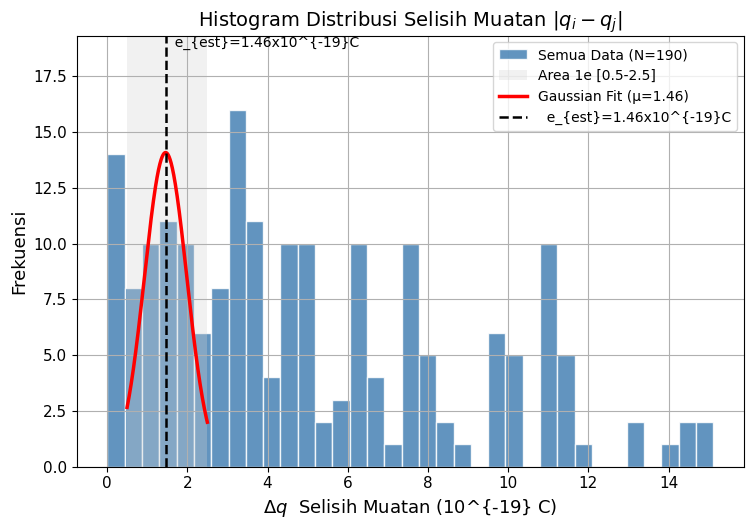

--- BILANGAN KUANTISASI ---
No   | qr (x1e-19)    | qf (x1e-19)    | qavg (x1e-19)  | n    | e_est (x1e-19)  
------------------------------------------------------------------------------
   1 |         12.168 |          5.086 |          8.627 |    6 |            1.438
   2 |         18.624 |         20.767 |         19.696 |   13 |            1.515
   3 |          5.390 |          6.311 |          5.850 |    4 |            1.463
   4 |          5.045 |          4.125 |          4.585 |    3 |            1.528
   5 |         10.393 |         11.385 |         10.889 |    7 |            1.556
   6 |          9.123 |          7.898 |          8.510 |    6 |            1.418
   7 |          5.264 |          4.786 |          5.025 |    3 |            1.675
   8 |          8.936 |          7.724 |          8.330 |    6 |            1.388
   9 |          5.245 |          4.470 |          4.858 |    3 |            1.619
  10 |          5.121 |          5.339 |          5.230 |    4 |         

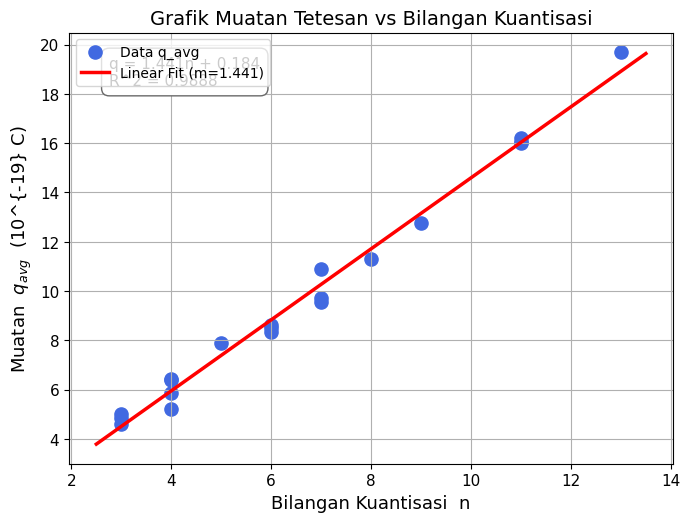

  TABEL ERROR RELATIF - METODE FLOATING (qf)
No   | qf (x1e-19 C)  | n    | q_teori (C)    | e dari qf      | Error (%) 
------------------------------------------------------------------------
   1 |        5.08619 |    6 |        9.61200 |        0.84770 |      47.09
   2 |       20.76746 |   13 |       20.82600 |        1.59750 |       0.28
   3 |        6.31061 |    4 |        6.40800 |        1.57765 |       1.52
   4 |        4.12487 |    3 |        4.80600 |        1.37496 |      14.17
   5 |       11.38470 |    7 |       11.21400 |        1.62639 |       1.52
   6 |        7.89786 |    6 |        9.61200 |        1.31631 |      17.83
   7 |        4.78621 |    3 |        4.80600 |        1.59540 |       0.41
   8 |        7.72419 |    6 |        9.61200 |        1.28736 |      19.64
   9 |        4.46986 |    3 |        4.80600 |        1.48995 |       6.99
  10 |        5.33886 |    4 |        6.40800 |        1.33472 |      16.68
  11 |        7.93741 |    5 |        8.01000 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# KONSTANTA DAN PARAMETER

eta = 1.85e-5
g = 9.81
rho_o = 875
rho_f = 1.29
l = 6.00e-3
d = 1.00e-3
e_real = 1.602e-19
drho = rho_o - rho_f


# DATA PENGAMATAN

raw = np.array([
   [10.04,  584.00,   4.07,  403.00],
    [5.01,  581.00,   5.82,  280.00],
   [11.47,  580.00,  13.30,  266.00],
   [11.80,  580.00,  14.41,  390.00],
    [7.57,  579.00,   8.21,  275.00],
   [16.98,  580.00,   3.63,  118.00],
   [12.99,  579.00,  10.93,  291.00],
    [8.38,  576.00,   9.16,  348.00],
   [14.77,  578.00,   9.01,  257.00],
   [12.92,  577.00,  11.70,  263.00],
    [8.75,  437.30,  24.06,  317.40],
    [8.00,  235.60,  24.92,  181.30],
   [12.46,  235.10,  23.04,  153.10],
    [6.82,  294.20,  24.79,  226.00],
   [12.60,  357.90,  21.76,  226.00],
    [9.31,  233.00,  31.94,  179.80],
    [7.19,  264.20,  27.14,  208.60],
   [11.17,  287.70,  19.71,  181.80],
   [28.31,  113.30,  43.30,   67.30],
   [15.61,  142.50,  28.82,   94.50]
])
N = raw.shape[0]
td = raw[:, 0]
tu = raw[:, 2]
Us = raw[:, 3]
Ur = raw[:, 1]


# HITUNG Vd, Vu, r, qf, qr, qavg

Vd = d / td
Vu = d / tu
r = np.sqrt((9. * eta * Vd) / (2. * g * drho))
sqrt_term = np.sqrt((eta * Vd) / (2. * g * drho))
qf = (18. * np.pi * eta * l * Vd / Us) * sqrt_term
qr = (18. * np.pi * eta * l * (Vd + Vu) / Ur) * sqrt_term
qavg = (qf + qr) / 2

print('===================================================================================')
print('  No |    Vd (m/s)  |    Vu (m/s)  |    r (m)     |    qf (C)    |    qr (C)    |   qavg (C)')
print('===================================================================================')
for i in range(N):
   print(f'  {i+1:2d} | {Vd[i]:10.4e} | {Vu[i]:10.4e} | {r[i]:10.4e} | {qf[i]:10.4e} | {qr[i]:10.4e} | {qavg[i]:10.4e}')
print('===================================================================================\n')

# MATRIKS SELISIH BERPASANGAN (190 kombinasi)

diff_list = []
print('--- MATRIKS SELISIH |qi - qj| (x10^-19 C) - Segitiga Bawah ---')
print(f'{'':5s}', ''.join([f'{j:8d}' for j in range(1, N + 1)]))
print(f'{'-' * (5 + 8 * N)}')
for i in range(N):
   row_str = f'{i+1:3d}  '
   for j in range(N):
       if j < i:
           val = abs(qavg[i] - qavg[j])
           diff_list.append(val)
           row_str += f'{val*1e19:8.3f}'
       elif j == i:
           row_str += f'{'--':8s}'
       else:
           row_str += f'{'':8s}'
   print(row_str)

diff_list = np.array(diff_list)
print(f'\nTotal kombinasi: {len(diff_list)}\n')
dq = diff_list * 1e19


# HISTOGRAM + GAUSSIAN FIT

lb = 0.50
ub = 2.50
peak1 = dq[(dq >= lb) & (dq <= ub)]
n1 = len(peak1)
mu1 = np.mean(peak1)
s1 = np.std(peak1)
SE1 = s1 / np.sqrt(n1)
e_hist = mu1 * 1e-19
print('--- HASIL GAUSSIAN FIT (Puncak 1e) ---')
print(f'  Filter  : [{lb:.2f}, {ub:.2f}] x10^-19 C')
print(f'  n data  : {n1}')
print(f'  e_hist  = ({mu1:.4f} +- {SE1:.4f}) x10^-19 C')
print(f'  Galat   : {abs(e_hist-e_real)/e_real*100:.2f}%\n')

# Plot Histogram
histogram_facecolor = 'steelblue'
fill_between_color = 'lightgray'

plt.figure(num='Histogram Selisih Muatan', figsize=(8.6, 5.6))
plt.hist(dq, bins=35, facecolor=histogram_facecolor,
   edgecolor='white', alpha=0.85, label='Semua Data (N=190)')
# plt.hold(True) is deprecated and removed
ylims = plt.ylim()
ymax = ylims[1] * 1.15
plt.ylim([0, ymax])
plt.fill_between([lb, ub], [0, 0], [ymax, ymax], color=fill_between_color,
   alpha=0.30, edgecolor='none', label=f'Area 1e [{lb:.1f}-{ub:.1f}]')
bin_width = (np.max(dq) - np.min(dq)) / 35 # MATLAB's histogram computes bin width differently, so recompute
x_fit = np.linspace(lb, ub, 400)
g_fit = (n1 * bin_width) * (1 / (s1 * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_fit - mu1) / s1)**2)
plt.plot(x_fit, g_fit, 'r-', linewidth=2.5,
   label=f'Gaussian Fit (\u03BC={mu1:.2f})') # \u03BC is unicode for mu
plt.axvline(mu1, color='k', linestyle='--', linewidth=1.8,
   label=r'  e_{est}=' f'{mu1:.2f}' r'x10^{-19}C') # Corrected for LaTeX math and f-string
plt.text(mu1, ymax, r'  e_{est}=' f'{mu1:.2f}' r'x10^{-19}C', ha='left', va='top', fontsize=10) # Corrected for LaTeX math and f-string
plt.xlabel(r'$\Delta q$  Selisih Muatan (10^{-19} C)', fontsize=13) # Corrected for LaTeX math
plt.ylabel('Frekuensi', fontsize=13)
plt.title('Histogram Distribusi Selisih Muatan $|q_i - q_j|$', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True)
plt.box(True)
plt.tick_params(axis='both', which='major', labelsize=11)
# plt.hold(False) is deprecated and removed
plt.show()


# BILANGAN KUANTISASI

n_q = np.round(qavg / e_hist).astype(int)
e_est = qavg / n_q
print('--- BILANGAN KUANTISASI ---')
print(f'{'No':4s} | {'qr (x1e-19)':14s} | {'qf (x1e-19)':14s} | {'qavg (x1e-19)':14s} | {'n':4s} | {'e_est (x1e-19)':16s}')
print(f'{'-' * 78}')
for i in range(N):
   print(f'{i+1:4d} | {qr[i]*1e19:14.3f} | {qf[i]*1e19:14.3f} | {qavg[i]*1e19:14.3f} | {n_q[i]:4d} | {e_est[i]*1e19:16.3f}')
print('\n')


# STEP 5 - REGRESI LINEAR

x_r = n_q.astype(float)
y_r = qavg
p_fit = np.polyfit(x_r, y_r, 1)
m_reg = p_fit[0]
c_reg = p_fit[1]
y_hat = np.polyval(p_fit, x_r)
SSres = np.sum((y_r - y_hat)**2)
SStot = np.sum((y_r - np.mean(y_r))**2)
R2 = 1 - SSres / SStot
s_yx = np.sqrt(SSres / (len(x_r) - 2))
Sxx = np.sum((x_r - np.mean(x_r))**2)
Sm = s_yx / np.sqrt(Sxx)
e_regr = m_reg
print('--- HASIL REGRESI LINEAR ---')
print(f'  qavg = {m_reg*1e19:.4f}*n + {c_reg*1e19:.4f}  (x10^-19 C)')
print(f'  e_regr = ({m_reg*1e19:.4f} +- {Sm*1e19:.4f}) x10^-19 C')
print(f'  R^2     = {R2:.4f}')
print(f'  Galat  : {abs(e_regr-e_real)/e_real*100:.2f}%\n')

# Plot Regresi
scatter_plot_color = 'royalblue'
bbox_edge_color = 'dimgray'

plt.figure(num='Regresi Linear', figsize=(7.8, 5.6))
plt.scatter(x_r, y_r*1e19, s=90, color=scatter_plot_color, label='Data q_avg') # Changed color to tuple
# plt.hold(True) is deprecated and removed
x_line = np.linspace(np.min(x_r) - 0.5, np.max(x_r) + 0.5, 300)
plt.plot(x_line, np.polyval(p_fit, x_line)*1e19,'r-', linewidth=2.5,
   label=f'Linear Fit (m={m_reg*1e19:.3f})')
plt.annotate(f'q = {m_reg*1e19:.3f}n + {c_reg*1e19:.3f}\nR^2 = {R2:.4f}',
             xy=(0.14, 0.78), xycoords='figure fraction',
             bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=bbox_edge_color, lw=1),
             fontsize=11)
plt.xlabel('Bilangan Kuantisasi  n', fontsize=13)
plt.ylabel(r'Muatan  $q_{avg}$  (10^{-19} C)', fontsize=13) # Corrected for LaTeX math
plt.title('Grafik Muatan Tetesan vs Bilangan Kuantisasi', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True)
plt.box(True)
plt.tick_params(axis='both', which='major', labelsize=11)
# plt.hold(False) is deprecated and removed
plt.show()


# STEP 6 - TABEL ERROR RELATIF qf & qr

# Error (%) = |q_terukur - n*e_real| / (n*e_real) * 100

q_teori = n_q * e_real   # nilai teoritis per tetesan (C)
err_qf = np.abs(qf - q_teori) / q_teori * 100   # error qf (%)
err_qr = np.abs(qr - q_teori) / q_teori * 100   # error qr (%)
err_qavg = np.abs(qavg - q_teori) / q_teori * 100   # error qavg (%)
e_dari_qf = qf / n_q   # nilai e estimasi dari qf
e_dari_qr = qr / n_q   # nilai e estimasi dari qr

# Tabel Error qf
print('========================================================================')
print('  TABEL ERROR RELATIF - METODE FLOATING (qf)')
print('========================================================================')
print(f'{'No':4s} | {'qf (x1e-19 C)':14s} | {'n':4s} | {'q_teori (C)':14s} | {'e dari qf':14s} | {'Error (%)':10s}')
print(f'{'-' * 72}')
for i in range(N):
   print(f'{i+1:4d} | {qf[i]*1e19:14.5f} | {n_q[i]:4d} | {q_teori[i]*1e19:14.5f} | {e_dari_qf[i]*1e19:14.5f} | {err_qf[i]:10.2f}')
print(f'{'-' * 72}')
print(f'{'Avg':4s} | {'':14s} | {'':4s} | {'':14s} | {'':14s} | {np.mean(err_qf):10.2f}')
print('========================================================================\n')

# Tabel Error qr
print('========================================================================')
print('  TABEL ERROR RELATIF - METODE RISING (qr)')
print('========================================================================')
print(f'{'No':4s} | {'qr (x1e-19 C)':14s} | {'n':4s} | {'q_teori (C)':14s} | {'e dari qr':14s} | {'Error (%)':10s}')
print(f'{'-' * 72}')
for i in range(N):
   print(f'{i+1:4d} | {qr[i]*1e19:14.5f} | {n_q[i]:4d} | {q_teori[i]*1e19:14.5f} | {e_dari_qr[i]*1e19:14.5f} | {err_qr[i]:10.2f}')
print(f'{'-' * 72}')
print(f'{'Avg':4s} | {'':14s} | {'':14s} | {'':14s} | {'':14s} | {np.mean(err_qr):10.2f}')
print('========================================================================\n')

# Tabel semua error
print('=======================================================')
print('  RINGKASAN ERROR RELATIF SEMUA TETESAN')
print('=======================================================')
print(f'{'No':4s} | {'Error qf (%)':12s} | {'Error qr (%)':12s} | {'Error qavg (%)':12s}')
print(f'{'-' * 50}')
for i in range(N):
   print(f'{i+1:4d} | {err_qf[i]:12.2f} | {err_qr[i]:12.2f} | {err_qavg[i]:12.2f}')
print(f'{'-' * 50}')
print(f'{'Avg':4s} | {np.mean(err_qf):12.2f} | {np.mean(err_qr):12.2f} | {np.mean(err_qavg):12.2f}')
print('=======================================================\n')

In [ ]:
import numpy as np

overall_mean_err_qf = np.mean(err_qf)
overall_mean_err_qr = np.mean(err_qr)
overall_mean_err_qavg = np.mean(err_qavg)

print(f"Mean Absolute Error for Floating Method (qf): {overall_mean_err_qf:.2f}%")
print(f"Mean Absolute Error for Rising Method (qr): {overall_mean_err_qr:.2f}%")
print(f"Mean Absolute Error for Average Method (qavg): {overall_mean_err_qavg:.2f}%")

overall_mean_absolute_error = np.mean([overall_mean_err_qf, overall_mean_err_qr, overall_mean_err_qavg])
print(f"\nOverall Mean Absolute Error across all methods: {overall_mean_absolute_error:.2f}%")

NameError: name 'np' is not defined